# Curtailment and Heating Sector

## imports

In [ ]:
import pandas as pd
import pypsa
import pycountry
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import combinations
import matplotlib.dates as mdates

## Load Network

In [ ]:
file_path ="C:\\Users\\user\\Pictures\\Ember-Flexibility-Study\\results\\scenario_2030_flex_on\\networks\\base_s_39__23H_2030.nc"
n = pypsa.Network(file_path)

### Curtailment

#### Assign country to each generator based on its bus

In [ ]:
n.generators["country"] = n.buses["country"][n.generators.bus].values
countries = ["DE", "NL", "IT", "PL", "CZ", "GR"]
color_dict = {
    "onwind": "#235ebc",
    "solar": "#f9d002",
    "offwind-ac": "#6895dd"
}

#### Calculate total curtailed GWh for multiple carriers

In [ ]:
carriers = ['onwind', 'solar', 'offwind-ac']
curtailment_gwh = {country: {} for country in countries}
for country in countries:
    for carr in carriers:
        sel = (n.generators.country == country) & (n.generators.carrier == carr)
        if not sel.any():
            continue
        indices = n.generators.index[sel]
        p_available = n.generators_t.p_max_pu[indices].multiply(n.generators.p_nom_opt[indices], axis=1).sum(axis=1)
        p_dispatched = n.generators_t.p[indices].sum(axis=1)
        p_curtailed = p_available - p_dispatched
        p_curtailed[p_curtailed < 0] = 0
        total_curtailed_gwh = (p_curtailed * n.snapshot_weightings.generators.loc[p_curtailed.index]).sum() / 1e3  # MWh to GWh
        curtailment_gwh[country][carr] = total_curtailed_gwh
        print(f"Total curtailed GWh for {country} ({carr}): {total_curtailed_gwh}")

#### Plot

In [ ]:
fig_pie, axs_pie = plt.subplots(3, 2, figsize=(12, 18))

for i, country in enumerate(countries):
    row, col = divmod(i, 2)
    ax = axs_pie[row, col]
    
    data = curtailment_gwh[country]
    if sum(list(data.values())) == 0:
        ax.text(0.5, 0.5, f"No curtailment in {country}", ha="center")
        continue
    
    labels = list(data.keys())
    values = list(data.values())
    colors = [color_dict.get(carr, '#cccccc') for carr in labels]
    
    def autopct_func(pct):
        total = sum(values)
        val = pct * total / 100
        return f'{val:.2f} GWh'
    
    wedges, texts, autotexts = ax.pie(values, labels=labels, autopct=autopct_func, startangle=90, colors=colors)
    ax.set_title(f"Curtailment GWh - {country}")
    ax.legend(wedges, labels, title="Carriers", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

### Heating Sector
The demand of various heating subsectors

In [6]:
load_stats = n.statistics.energy_balance(comps=["Load"], aggregate_time="sum")
heating_stats_GWh = load_stats[load_stats.index.get_level_values('carrier').str.contains('heat', case=False)]
heating_stats_GWh

component  carrier                            bus_carrier         
Load       low-temperature heat for industry  urban central heat     -1.621500e+08
                                              urban decentral heat   -2.000000e+04
           rural heat                         rural heat             -6.096245e+08
           urban central heat                 urban central heat     -5.814780e+08
           urban decentral heat               urban decentral heat   -1.579796e+09
Name: objective, dtype: float64

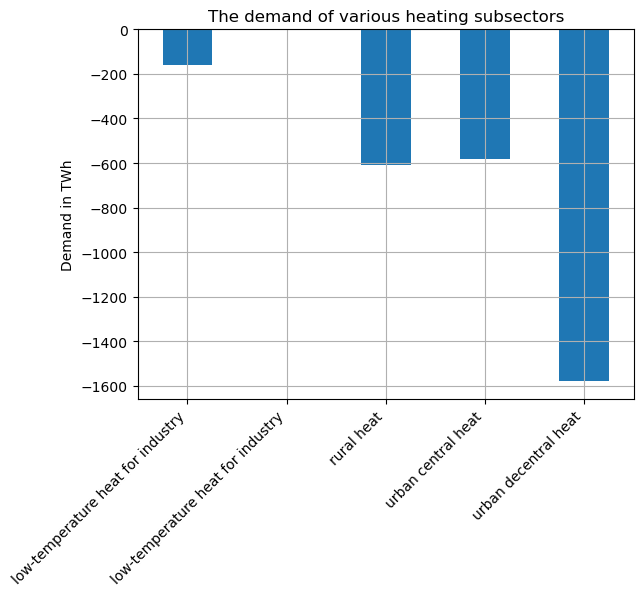

In [7]:
heating_stats_TWh = heating_stats_GWh/1000000

ax = heating_stats_TWh.plot.bar(
    title='The demand of various heating subsectors',
    xlabel="",
    ylabel="Demand in TWh"
)

ax.set_xticklabels(heating_stats_TWh.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True)
plt.show()

How is heating energy supplied (heat pump, district heating, resistive heater, gas boiler)

Gas Boiler: 1295701068.63405 MWh
Heat Pump: 1076982065.57835 MWh
Resistive Heater: 139487666.4494 MWh
CHP: 925193161.34698 MWh


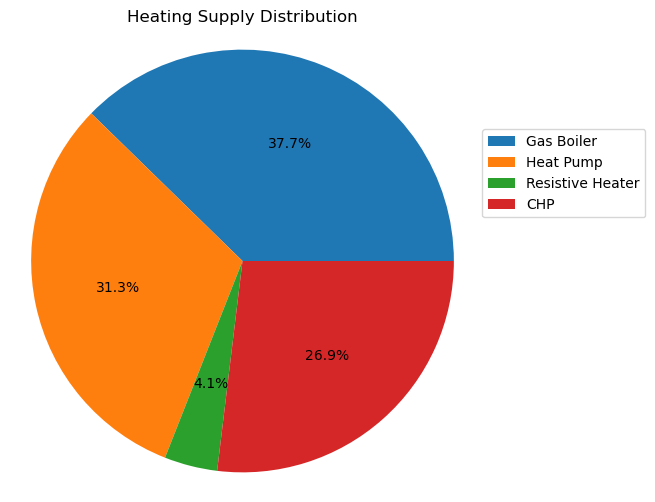

In [8]:
heating_supply_stats = n.statistics.supply(comps=["Link"], aggregate_time="sum").loc[
    lambda x: x.index.get_level_values('carrier').str.contains('heat|boiler|pump|chp', case=False)
]

# Only the Gas boiler, heat pump, CHP, and resistive heater technologies are considered here
heating_types = ['Gas Boiler', 'Heat Pump', 'Resistive Heater', 'CHP']
heating_sums = [heating_supply_stats[heating_supply_stats.index.get_level_values('carrier').str.contains(heatingtype, case=False)].sum() for heatingtype in heating_types]

for ht, sum_value in zip(heating_types, heating_sums):
    print(f"{ht}: {sum_value} MWh")

plt.figure(figsize=(6, 6))
plt.pie(heating_sums, autopct='%1.1f%%')
plt.title('Heating Supply Distribution')
plt.legend(heating_types, loc='upper left', bbox_to_anchor=(1, 0.8))
plt.axis('equal')
plt.show()